# BDD100K Grad-CAM Demo
Loads a small subset of BDD100K images and visualizes Grad-CAM overlays using a pre-trained ResNet.

In [9]:
import sys, os
PROJECT_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd())=='notebooks' else os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)
os.chdir(PROJECT_ROOT)


Project root: /Users/tony/Documents/CSC790_001_XAI_Papers/Explaining-Autonomous-Vehicle-Decisions


In [16]:
from pathlib import Path
import torch
from torchvision import models, transforms
from src.utils.config import load_config
from src.xai.grad_cam import GradCAM, overlay_heatmap
from src.data.bdd100k import ImageFolderFlat
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image 
import os
torch.set_grad_enabled(True)

In [17]:
cfg = load_config('configs/config.yaml')
data_root = Path(cfg.data.bdd100k_root)
out_dir = Path(cfg.xai.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)
print('Data root:', data_root)
print('Output dir:', out_dir)

Data root: data/bdd100k_subset
Output dir: outputs/gradcam


In [18]:
# Preprocess for ResNet
preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
dataset = ImageFolderFlat(str(data_root), split='val', transform=preprocess, limit=16)
len(dataset)

16

In [19]:
# Load pretrained model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
target_layer = model.layer4[-1]
cam = GradCAM(model, target_layer)
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
device

device(type='cpu')

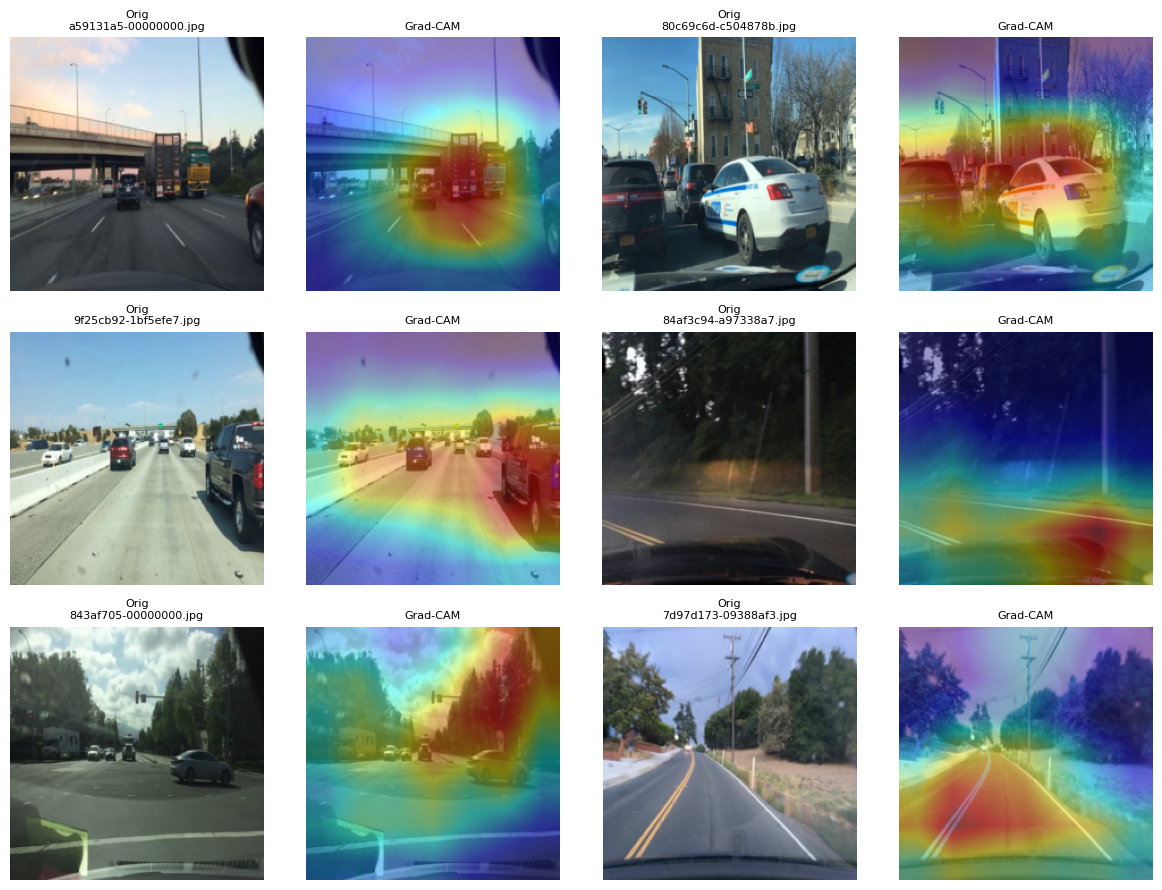

Saved slide-ready images to outputs/gradcam


In [20]:
# Run Grad-CAM on N images and save slide-ready side-by-side visuals
import imageio

N = min(6, len(dataset))  # 6 examples -> 3x4 grid (orig/overlay pairs)
rows = 3
cols = 4  # 2 per example: [orig, overlay]

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 3 * rows))
axes = axes.reshape(rows, cols)

for i in range(N):
    img_t, path = dataset[i]
    inp = img_t.unsqueeze(0).to(device)
    heatmap = cam.generate(inp)

    # Convert back to uint8 original image
    img_np = img_t.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
    img_np = np.clip(img_np, 0, 1)
    img_uint8 = (img_np * 255).astype(np.uint8)

    # Grad-CAM overlay
    overlay = overlay_heatmap(img_uint8, heatmap)

    # Save individual images for PPT
    base_name = Path(path).stem
    orig_path = out_dir / f"{base_name}_orig.jpg"
    overlay_path = out_dir / f"{base_name}_gradcam.jpg"
    side_by_side_path = out_dir / f"{base_name}_side_by_side.jpg"

    imageio.imwrite(orig_path, img_uint8)
    imageio.imwrite(overlay_path, overlay)

    # Side-by-side for convenience
    side_by_side = np.concatenate([img_uint8, overlay], axis=1)
    imageio.imwrite(side_by_side_path, side_by_side)

    r = i // 2
    c = (i % 2) * 2
    # Original on left
    axes[r, c].imshow(img_uint8)
    axes[r, c].set_title(f"Orig\n{Path(path).name}", fontsize=8)
    axes[r, c].axis("off")
    # Overlay on right
    axes[r, c + 1].imshow(overlay)
    axes[r, c + 1].set_title("Grad-CAM", fontsize=8)
    axes[r, c + 1].axis("off")

# Hide any unused subplots
for r in range(rows):
    for c in range(cols):
        if r * 2 + c // 2 >= N:
            axes[r, c].axis("off")

plt.tight_layout()
plt.show()

print(f"Saved slide-ready images to {out_dir}")

## Extra Grad-CAM examples (segmentation images)

The cells below generate additional Grad-CAM visuals from the BDD100K segmentation images (`data/bdd100k_seg`). This gives a bit more variety for the presentation gallery.

Found 6 segmentation images for Grad-CAM demos


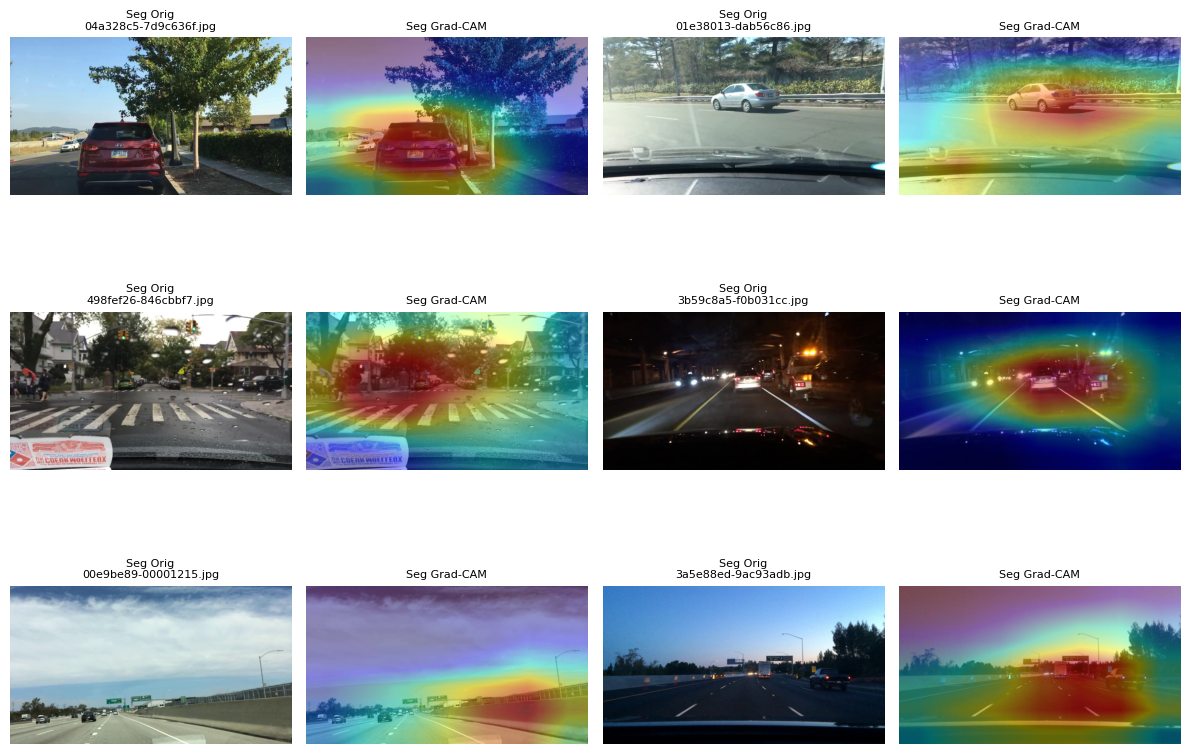

Saved extra segmentation Grad-CAM images to outputs/gradcam


In [33]:
# Grad-CAM on BDD100K segmentation images (if available)
from glob import glob
import cv2

seg_root = Path('data/bdd100k_seg/bdd100k/seg/images')
if seg_root.exists():
    seg_paths = glob(str(seg_root / 'train' / '*.jpg'))[:6]
    print(f"Found {len(seg_paths)} segmentation images for Grad-CAM demos")

    rows, cols = 3, 4
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = axes.reshape(rows, cols)

    for i, p in enumerate(seg_paths):
        img_pil = Image.open(p).convert('RGB')
        orig_np = np.array(img_pil)

        inp = preprocess(img_pil).unsqueeze(0).to(device)
        heatmap = cam.generate(inp)

        # Resize heatmap to match original image size (H, W)
        H, W = orig_np.shape[:2]
        heatmap_resized = cv2.resize(heatmap, (W, H))

        overlay = overlay_heatmap(orig_np, heatmap_resized)

        base = Path(p).stem
        out_orig = out_dir / f"seg_{base}_orig.jpg"
        out_overlay = out_dir / f"seg_{base}_gradcam.jpg"
        out_side = out_dir / f"seg_{base}_side_by_side.jpg"

        imageio.imwrite(out_orig, orig_np)
        imageio.imwrite(out_overlay, overlay)
        side = np.concatenate([orig_np, overlay], axis=1)
        imageio.imwrite(out_side, side)

        r = i // 2
        c = (i % 2) * 2
        axes[r, c].imshow(orig_np)
        axes[r, c].set_title(f"Seg Orig\n{Path(p).name}", fontsize=8)
        axes[r, c].axis('off')
        axes[r, c+1].imshow(overlay)
        axes[r, c+1].set_title("Seg Grad-CAM", fontsize=8)
        axes[r, c+1].axis('off')

    for r in range(rows):
        for c in range(cols):
            if r * 2 + c // 2 >= len(seg_paths):
                axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Saved extra segmentation Grad-CAM images to {out_dir}")
else:
    print("Segmentation images folder not found at", seg_root)

## Detailed examples: original vs heatmap vs overlay

The next cell builds paper-style figures for a few images:
- Column 1: original image
- Column 2: Grad-CAM heatmap only
- Column 3: Grad-CAM overlay

You can screenshot or export these for the slides.

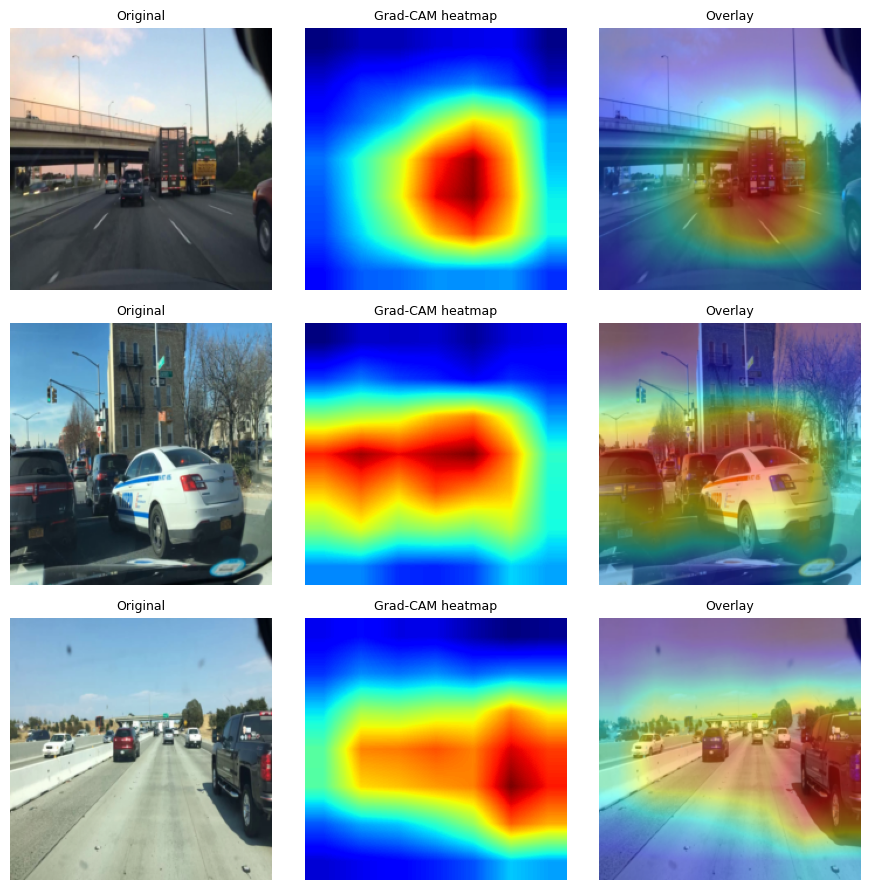

Generated detailed original/heatmap/overlay figures.


In [34]:
# Original vs heatmap vs overlay for a few curated examples

import matplotlib.colors as mcolors

K = min(3, len(dataset))  # number of detailed examples
fig, axes = plt.subplots(K, 3, figsize=(9, 3 * K))

for i in range(K):
    img_t, path = dataset[i]
    inp = img_t.unsqueeze(0).to(device)
    heatmap = cam.generate(inp)

    # De-normalize to original image
    img_np = img_t.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
    img_np = np.clip(img_np, 0, 1)
    img_uint8 = (img_np * 255).astype(np.uint8)

    # Heatmap only (no overlay)
    hm = (heatmap * 255).astype(np.uint8)

    # For consistent colorbar, normalize
    ax_orig = axes[i, 0]
    ax_hm = axes[i, 1]
    ax_ov = axes[i, 2]

    ax_orig.imshow(img_uint8)
    ax_orig.set_title("Original", fontsize=9)
    ax_orig.axis("off")

    im_hm = ax_hm.imshow(hm, cmap="jet")
    ax_hm.set_title("Grad-CAM heatmap", fontsize=9)
    ax_hm.axis("off")

    ov = overlay_heatmap(img_uint8, heatmap)
    ax_ov.imshow(ov)
    ax_ov.set_title("Overlay", fontsize=9)
    ax_ov.axis("off")

plt.tight_layout()
plt.show()
print("Generated detailed original/heatmap/overlay figures.")

## Simple faithfulness check (optional quantitative slide)

This cell performs a tiny masking experiment:
- Compute model confidence for the predicted class.
- Mask the top-k% most salient pixels (from Grad-CAM) and recompute confidence.
- Plot average confidence drop vs. masking level.

Even a small plot from this looks more \"paper-like\" on a slide.

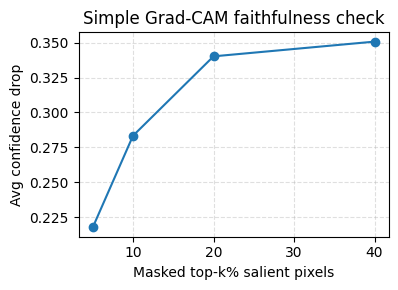

Base mean confidence: 0.3548900216817856
k=5% -> avg confidence drop: 0.2176
k=10% -> avg confidence drop: 0.2833
k=20% -> avg confidence drop: 0.3402
k=40% -> avg confidence drop: 0.3507


In [35]:
# Simple masking-based faithfulness check

import torch.nn.functional as F

mask_levels = [5, 10, 20, 40]  # percentage of most salient pixels to mask
n_samples = min(10, len(dataset))

base_confs = []
masked_confs = {k: [] for k in mask_levels}

for i in range(n_samples):
    img_t, path = dataset[i]
    inp = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(inp)
        probs = F.softmax(logits, dim=1)
        top_prob, top_idx = probs.max(dim=1)
    base_confs.append(top_prob.item())

    heatmap = cam.generate(inp)  # H x W, assumed in [0,1]

    # Flatten and sort by saliency
    flat = heatmap.reshape(-1)
    sorted_idx = np.argsort(-flat)  # descending

    H, W = heatmap.shape

    for k in mask_levels:
        num_mask = int(len(flat) * (k / 100.0))
        mask = np.ones_like(flat, dtype=np.float32)
        mask[sorted_idx[:num_mask]] = 0.0
        mask = mask.reshape(H, W)

        # Upsample mask to match input size (if needed)
        mask_t = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).float().to(device)
        mask_up = F.interpolate(mask_t, size=inp.shape[-2:], mode="bilinear", align_corners=False)
        mask_up = mask_up.squeeze(0)

        # Apply mask (zero out important pixels)
        inp_masked = inp * mask_up

        with torch.no_grad():
            logits_m = model(inp_masked)
            probs_m = F.softmax(logits_m, dim=1)
            conf_m = probs_m[0, top_idx].item()
        masked_confs[k].append(conf_m)

# Compute average confidence drop
base_mean = np.mean(base_confs)
drops = []
for k in mask_levels:
    m_mean = np.mean(masked_confs[k])
    drops.append(base_mean - m_mean)

plt.figure(figsize=(4,3))
plt.plot(mask_levels, drops, marker='o')
plt.xlabel('Masked top-k% salient pixels')
plt.ylabel('Avg confidence drop')
plt.title('Simple Grad-CAM faithfulness check')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Base mean confidence:", base_mean)
for k, d in zip(mask_levels, drops):
    print(f"k={k}% -> avg confidence drop: {d:.4f}")